In [17]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import os

In [ ]:

# Fixed Variables
GRAVITY = 9.806781  # gravity in m/s^2
mass = [0.10548177618443695, 0.07619744360415454]
length = [0.05, 0.05]
coulomb_fric = [0.00305,0.0007777]
damping = [7.634058385430087e-12, 0.0005106535523065844]

l1, l2 = length
m1, m2 = mass
b1, b2 = damping
mu1, mu2 = coulomb_fric

PEAK_TORQUE = 0.04  # peak torque in Nm
torque_limits = jnp.array([-PEAK_TORQUE, PEAK_TORQUE])  # torque limits in Nm


Q = jnp.diag(jnp.array([100.0, 100.0, 1.0, 1.0]))
Qfin =  Q
R = jnp.diag(jnp.array([1, 1])) * 0.01
max_torque = 0.07      # Physical Hard Stop
# Initialize x_traj with random positions, but keep start and end fixed
# key = jax.random.PRNGKey(42)
key = jax.random.PRNGKey(0)


path_prefix = os.getcwd() + "/temp_images/"
# read tbe optimal trajectory from file
x_ref = np.loadtxt("trajectory.csv", delimiter=",", skiprows=1).T
u_ref = np.loadtxt("inputs.csv", delimiter=",", skiprows=1).T

# Generate the noise array 
base_std = jnp.array([0.002, 0.002, 0.05, 0.05]) 
# mult = 0.0
mult = 1.0
# mult = 4.0


noise_traj = mult * jax.random.normal(key, shape=x_ref.shape) * base_std[:, None]



In [19]:
# Dynamic's Matrices
def M(q):
	q1, q2, _, _ = q
	m00 = l1**2 * m1 + l2**2 * m2 + l1**2 * m2 + 2 * l1 * m2 * l2 * jnp.cos(q2)
	m01 = l2**2 * m2 + l1 * m2 * l2 * jnp.cos(q2)
	m10 = l2**2 * m2 + l1 * m2 * l2 * jnp.cos(q2)
	m11 = l2**2 * m2
	return jnp.array([[m00, m01], [m10, m11]])

def C(q):
	q1, q2, q1_dot, q2_dot = q
	c00 = -2 * q2_dot * l1 * m2 * l2 * jnp.sin(q2)
	c01 = -q2_dot * l1 * m2 * l2 * jnp.sin(q2)
	c10 = q1_dot * l1 * m2 * l2 * jnp.sin(q2)
	c11 = 0.0
	return jnp.array([[c00, c01], [c10, c11]])

def G(q):
	q1, q2, _, _ = q
	g00 = -GRAVITY * m1 * l1 * jnp.sin(q1) - GRAVITY * m2 * (l1 * jnp.sin(q1) + l2 * jnp.sin(q1 + q2))
	g10 = -GRAVITY * m2 * l2 * jnp.sin(q1 + q2)
	return jnp.array([[g00], [g10]])
def F(q_dot):
	q_dot = q_dot.flatten()
	f1 = b1 * q_dot[0] #+ mu1 * jnp.arctan(100*q_dot[0])
	f2 = b2 * q_dot[1] #+ mu2 * jnp.arctan(100*q_dot[1])
		
	return jnp.array([[f1], [f2]])
		

In [20]:
def wrap_to_pi(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


In [21]:
def angle_dif(x1, x2):
	"""xi = [q1, q2, q1_dot, q2_dot]
	wrap the angle differences to [-2pi, 2pi]
	"""
	diff = x1 - x2
	diff = diff.at[0].set(wrap_to_pi(diff[0]))
	diff = diff.at[1].set(wrap_to_pi(diff[1]))
	return diff
	

In [22]:
def to_feature_space(x):
	"""
	Expands state [p0, p1, v0, v1] to [cos(p0), sin(p0), cos(p1), sin(p1), 0.1*v0, 0.1*v1]
	"""
	# Weighting factor for velocity
	v_scale = 0.1 

	if x.ndim == 1:
		p0, p1 = x[0], x[1]
		v = x[2:] * v_scale
		return np.concatenate(([np.cos(p0), np.sin(p0), np.cos(p1), np.sin(p1)], v))
	else:
		p0, p1 = x[0, :], x[1, :]
		v = x[2:, :] * v_scale
		return np.vstack((np.cos(p0), np.sin(p0), np.cos(p1), np.sin(p1), v))

In [23]:
def dynamics(x, u):
    u = u.reshape(2, 1)
    
    dq = x[2:].reshape(2, 1)
    
    ddq = jnp.linalg.solve(M(x), u - C(x) @ dq + G(x) )
    
  
    return jnp.concatenate([dq, ddq]).flatten()

In [24]:
# create tests for the dynamics and F function
q = jnp.array([0.0, 0.0, 0.0, 0.0]).T
u = jnp.array([0.1, 0.1])
print(q[2:])
print("Dynamics test:", dynamics(q, u))
# q = --- IGNORE ---jnp.array([0.0, 0.0, 0.0, 0.0])
# u = --- IGNORE ---jnp.array([0.1, 0.1])


[0. 0.]
Dynamics test: [   0.         0.      -379.21246 1283.377  ]


In [25]:
def rk4(x, u, dynamics, dt=0.05):
    k1 = dynamics(x, u).flatten()
    k2 = dynamics(x + 0.5 * dt * k1, u).flatten()
    k3 = dynamics(x + 0.5 * dt * k2, u).flatten()
    k4 = dynamics(x + dt * k3, u).flatten()
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [26]:
def get_continuous_jacobians(x, u):
	f = lambda x, u: dynamics(x, u)
	A = jax.jacfwd(f, argnums=0)(x, u)
	B = jax.jacfwd(f, argnums=1)(x, u)
	return A, B

In [27]:
def get_discrete_matrices(x_k, u_k, t_dt=0.05):
    """
    Computes A_d and B_d using the chain rule on the RK4 step.
    """
    dt = t_dt
    nx = x_k.shape[0]
    nu = u_k.shape[0]
    I = np.eye(nx)
    
    # Stage 1
    # k1 = f(x, u)
    A1, B1 = get_continuous_jacobians(x_k, u_k)
    dk1_dx = A1
    dk1_du = B1
    
    # Stage 2
    # k2 = f(x + 0.5*dt*k1, u)
    x2 = x_k + 0.5 * dt * dynamics(x_k, u_k) 
    A2, B2 = get_continuous_jacobians(x2, u_k)
    
    # dk2/dx = A2 * (I + 0.5*dt*dk1/dx)
    dk2_dx = A2 @ (I + 0.5 * dt * dk1_dx)
    # dk2/du = A2 * (0.5*dt*dk1/du) + B2 
    dk2_du = A2 @ (0.5 * dt * dk1_du) + B2
    
    # Stage 3
    # k3 = f(x + 0.5*dt*k2, u)
    x3 = x_k + 0.5 * dt * dynamics(x_k + 0.5*dt*dynamics(x_k, u_k), u_k)
    A3, B3 = get_continuous_jacobians(x3, u_k)
    
    dk3_dx = A3 @ (I + 0.5 * dt * dk2_dx)
    dk3_du = A3 @ (0.5 * dt * dk2_du) + B3
    
    # Stage 4
    # k4 = f(x + dt*k3, u)
    k1_val = dynamics(x_k, u_k)
    k2_val = dynamics(x_k + 0.5*dt*k1_val, u_k)
    k3_val = dynamics(x_k + 0.5*dt*k2_val, u_k)
    x4 = x_k + dt * k3_val
    
    A4, B4 = get_continuous_jacobians(x4, u_k)
    
    dk4_dx = A4 @ (I + dt * dk3_dx)
    dk4_du = A4 @ (dt * dk3_du) + B4
    
    # Final Discrete Matrices
    # A_d = I + dt/6 * (dk1_dx + 2*dk2_dx + 2*dk3_dx + dk4_dx) 
    A_d = I + (dt / 6.0) * (dk1_dx + 2*dk2_dx + 2*dk3_dx + dk4_dx)
    
    # B_d = dt/6 * (dk1_du + 2*dk2_du + 2*dk3_du + dk4_du) 
    B_d = (dt / 6.0) * (dk1_du + 2*dk2_du + 2*dk3_du + dk4_du)
    
    return A_d, B_d


In [28]:
def tvlqr_backward_pass(P_next, inputs, Q_d, R_d, dt=0.05):
	x_k, u_k = inputs
	A_d, B_d = get_discrete_matrices(x_k, u_k, dt)
	S = R_d + B_d.T @ P_next @ B_d
	K_k = jnp.linalg.solve(S, B_d.T @ P_next @ A_d)
	P_k = Q_d + A_d.T @ P_next @ (A_d - B_d @ K_k)
	return P_k, K_k

In [ ]:
# Simulation parameters
T = 2.0  # Total simulation time in seconds
dt = 0.05
steps = int(T / dt)
time_span = jnp.linspace(0, T, steps)

# Initial state
x0 = jnp.array([0.0, 0.0, 0.0, 0.0])
xgoal = jnp.array([jnp.pi, 0.0, 0.0, 0.0])
# Storage for history
x_history = [x0]
u_history = []
force_history = []

# implement the tvlqr
P = [None] * steps
K = [None] * (steps - 1)
P[-1] = Qfin  # Terminal cost

Q_d = Q 
R_d = R 


# Prepare inputs for scan (reverse time from steps-2 down to 0)
# x_ref is (nx, steps), u_ref is (nu, steps)
xs_scan = x_ref[:, :-1].T[::-1]
us_scan = u_ref[:, :-1].T[::-1]

# Initial carry for backward pass is the terminal cost P[-1]
P_terminal = P[-1]

# Run the scan using jax.lax.scan
scan_fn = lambda p, inputs: tvlqr_backward_pass(p, inputs, Q_d, R_d, dt)
P_rev, K_rev = jax.lax.scan(scan_fn, P_terminal, (xs_scan, us_scan))
# Reverse the results to get forward time order and update P, K
P = np.concatenate([P_rev[::-1], P_terminal], axis=0)
K = K_rev[::-1]
# Save the K matrix to a file using numpy as a csv 
np.save("results/K_matrix.npy", np.array(K))
print(f"K dimensions: {len(K)} x {K[0].shape[0]} x {K[0].shape[1]}")
# Simulate with TVLQR controller
print("Starting TVLQR simulation...")


K dimensions: 40 x 2 x 4
Starting TVLQR simulation...


In [30]:

def get_ranked_distances(x, x_ref, k=1):
	"""
	Calculates distance in the Sin/Cos feature space.
	"""
	# Convert both current state and ref trajectory to feature space
	feat_x = to_feature_space(x)          # Shape (6,)
	feat_ref = to_feature_space(x_ref)    # Shape (6, N)
	
	# Calculate Euclidean distance in this new 6D space
	diff = feat_ref - feat_x.reshape(-1, 1)
	dists = np.linalg.norm(diff, axis=0)
	
	sorted_indices = np.argsort(dists)
	return sorted_indices[:k], dists[sorted_indices[:k]]

def get_x_ref(x, x_ref):

	idx, _ = get_ranked_distances(x, x_ref, k=1)
	return idx[0]

def get_K_gain_euclidean(x, x_ref, K, k=5):
	"""
	Returns a weighted average of the K matrices corresponding to the k closest
	points in the reference trajectory to the current state x.
	"""
	# Get top k closest indices and their distances
	indices, dists = get_ranked_distances(x, x_ref, k=k)
	eps = 1e-6
	w = 1.0 / (dists + eps)
	weights = w / np.sum(w)
	
	# Retrieve the K matrices for these indices
	# K is a list or array of shape (Steps, nu, nx). K[indices] gives (k, nu, nx)
	# K is a list in the context, convert to array for indexing if not already
	K_array = np.array(K)
	
	# Clip indices to ensure they are valid for K (which might have 1 less element than x_ref)
	indices_clipped = np.clip(indices, 0, len(K_array) - 1)
	Ks = K_array[indices_clipped]

	K_weighted = np.sum(weights[:, None, None] * Ks, axis=0)
	
	return K_weighted


In [31]:
x_current = x0
force_history_reg = []
x_history_reg = [x_current]
u_history_reg = []
stop_time =[150,158]
error = np.inf
error_threshold = 1

x_des = x_ref[:, 0]
u_des = u_ref[:, 0]
K_gain = K[0]
# --- SIMULATION PARAMETERS ---
dt_control = 0.05       # Control updates every 50ms
dt_sim = 0.01          # Physics updates every 1ms (Sub-stepping)
sim_steps = int(dt_control / dt_sim) # 50 physics steps per 1 control step
print(f"Sim steps per control step: {sim_steps}")
mode = "TRACKING"

dt = 0.05
current_idx = 0  
DEVIATION_THRESHOLD = 2.0    # threshold for switching to recovery 
mode = "TRACKING"
x_current = x0
max_idx = x_ref.shape[1] -1
print(max_idx)
for time_step in range(steps+200):
	

	# --- B. CHECK TRACKING STATUS ---
	target_state = x_ref[:, current_idx].reshape(4, 1)
	_, dists = get_ranked_distances(x_current, target_state, k=1)
	dist_to_target = dists[0]

	holding = (current_idx >= max_idx)

	if dist_to_target > DEVIATION_THRESHOLD or holding:
		mode = "RECOVERY"
		current_idx = get_x_ref(x_current, x_ref)
	else:
		mode = "TRACKING"

	# Select reference index and gains in one place
	idx = current_idx
	x_des = x_ref[:, idx]
	u_des = u_ref[:, idx]

	if mode == "TRACKING":
		K_gain = K[idx]
		current_idx += 1
	else:
		# HOLDING or RECOVERY
		K_gain = get_K_gain_euclidean(x_current, x_ref, K, k=5)

	# --- C. CONTROL CALCULATION ---
	error = np.array(x_current - x_des)
	# Wrap angles!
	error[0] = wrap_to_pi(error[0])
	error[1] = wrap_to_pi(error[1])

	u_feedback = -K_gain @ error        
	u_total = u_des + u_feedback
	# Clip to hardware limits
	u_total = np.clip(u_total, -max_torque, max_torque)
	if stop_time[0]<= time_step <= stop_time[1]:
		u_total = jnp.array([0.0,0.0])
		print(f"Stopping at time {time_step*dt_control}")
	x_sim = x_current	
	for _ in range(sim_steps):
		x_sim = rk4(x_sim, u_total, dynamics, dt_sim)
		

	# Add noise once per control interval
	x_next = x_sim 
	x_measurement = x_sim + noise_traj[:, min(current_idx, x_ref.shape[1]-1)]
	
	x_next = x_next.at[0].set((x_next[0] + np.pi) % (2 * np.pi) - np.pi)
	x_next = x_next.at[1].set((x_next[1] + np.pi) % (2 * np.pi) - np.pi)


	# Store histories
	force_history_reg.append(u_total)
	x_history_reg.append(x_measurement)
	x_current = x_next

Sim steps per control step: 5
40
Stopping at time 7.5
Stopping at time 7.550000000000001
Stopping at time 7.6000000000000005
Stopping at time 7.65
Stopping at time 7.7
Stopping at time 7.75
Stopping at time 7.800000000000001
Stopping at time 7.8500000000000005
Stopping at time 7.9


Padding Size: 199
Sum of Relative Error TVLQR: 1135.0263671875


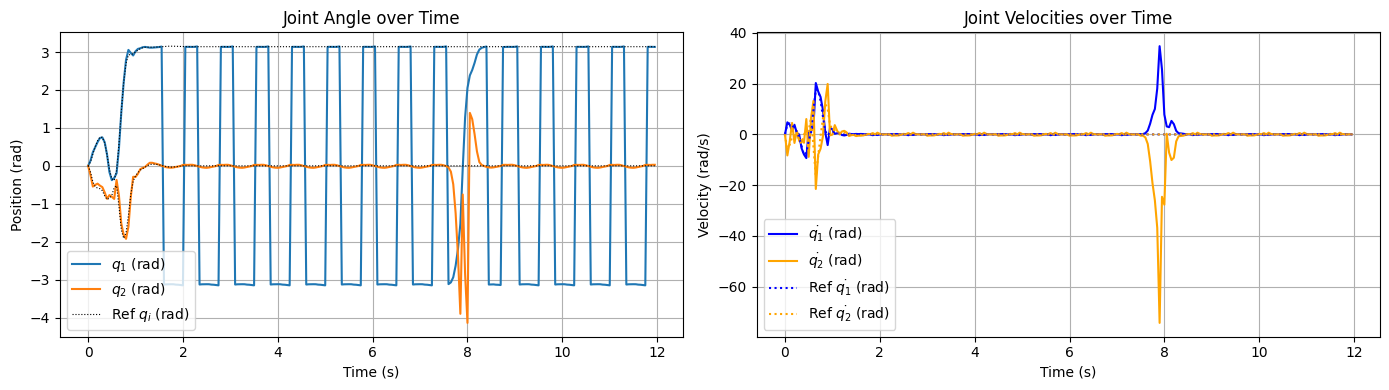

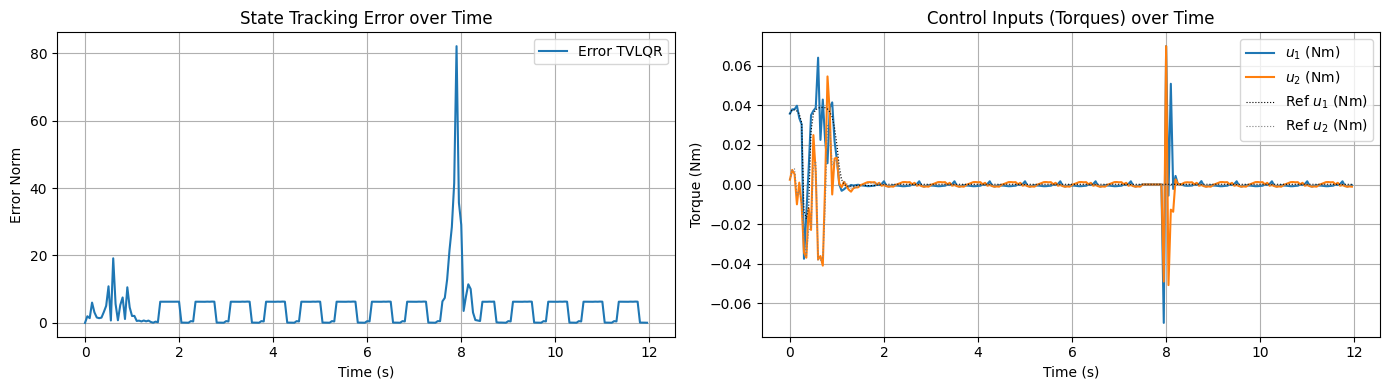

In [32]:
# Plots
# First, convert lists to arrays and trim the last starting element if necessary
x_history = jnp.array(x_history_reg)[:-1]
force_history = jnp.array(force_history_reg).reshape(-1, 2)

# Dynamic time span based on actual simulation length
actual_steps = x_history.shape[0]
time_span_clas = jnp.arange(actual_steps) * dt

r_diag = base_std * mult
filename1 = path_prefix+ f"Joint_positions_noise{int(r_diag[0]*1000)}_{int(r_diag[1]*1000)}_{int(r_diag[2]*1000)}_{int(r_diag[3]*1000)}.png"
filename2 = path_prefix+ f"Joint_velocities_noise{int(r_diag[0]*1000)}_{int(r_diag[1]*1000)}_{int(r_diag[2]*1000)}_{int(r_diag[3]*1000)}.png"
filename3 = path_prefix+ f"Error_noise{int(r_diag[0]*1000)}_{int(r_diag[1]*1000)}_{int(r_diag[2]*1000)}_{int(r_diag[3]*1000)}.png"
filename4 = path_prefix+ f"Torques_noise{int(r_diag[0]*1000)}_{int(r_diag[1]*1000)}_{int(r_diag[2]*1000)}_{int(r_diag[3]*1000)}.png"

# Pad the reference signals to match the ACTUAL simulation length
padding_needed = actual_steps - x_ref.shape[1]
print(f"Padding Size: {padding_needed}")

if padding_needed > 0:
	# Get the last column to use for padding
	x_ref_last = x_ref[:, -1:]
	u_ref_last = u_ref[:, -1:]

	# Create padding arrays
	x_padding = jnp.tile(x_ref_last, (1, padding_needed))
	u_padding = jnp.tile(u_ref_last, (1, padding_needed))

	# Append padding to the reference trajectories
	x_ref_padded = jnp.concatenate([x_ref, x_padding], axis=1)
	u_ref_padded = jnp.concatenate([u_ref, u_padding], axis=1)
else:
	# If simulation stopped early or matches exactly, slice or keep as is
	x_ref_padded = x_ref[:, :actual_steps]
	u_ref_padded = u_ref[:, :actual_steps]

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Plot Joint Angles
axs[0].plot(time_span_clas, x_history[:, 0], label=r'$q_1$ (rad)')
axs[0].plot(time_span_clas, x_history[:, 1], label=r'$q_2$ (rad)')
axs[0].plot(time_span_clas, x_ref_padded[0, :], ':', label='Ref $q_i$ (rad)', color='black', linewidth=0.8)
axs[0].plot(time_span_clas, x_ref_padded[1, :], ':', color='black', linewidth=0.8)
axs[0].set_title('Joint Angle over Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Position (rad)')
axs[0].legend(loc='lower left')
axs[0].grid(True)

# Plot Joint Velocities
axs[1].plot(time_span_clas, x_history[:, 2], label=r'$\dot{q_1}$ (rad)', color='blue')
axs[1].plot(time_span_clas, x_history[:, 3], label=r'$\dot{q_2}$ (rad)', color='orange')
axs[1].plot(time_span_clas, x_ref_padded[2, :], ':', label='Ref $\dot{q_1}$ (rad)', color='blue')
axs[1].plot(time_span_clas, x_ref_padded[3, :], ':', label='Ref $\dot{q_2}$ (rad)', color='orange')
axs[1].set_title('Joint Velocities over Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Velocity (rad/s)')
axs[1].legend(loc='lower left')
axs[1].grid(True)

plt.tight_layout()


error_clas = jnp.linalg.norm(x_history - x_ref_padded.T, axis=1)
print(f"Sum of Relative Error TVLQR: {jnp.sum(error_clas)}")

# Create a new figure with 2 subplots side-by-side
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Plot errors over time
axs[0].plot(time_span_clas, error_clas, label='Error TVLQR')
axs[0].set_title('State Tracking Error over Time')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Error Norm')
axs[0].grid(True)
axs[0].legend()

# Plot Forces (Torques)
axs[1].plot(time_span_clas, force_history[:len(time_span_clas), 0], label=r'$u_1$ (Nm)')
axs[1].plot(time_span_clas, force_history[:len(time_span_clas), 1], label=r'$u_2$ (Nm)')
axs[1].plot(time_span_clas, u_ref_padded[0, :], ':', label='Ref $u_1$ (Nm)', color ='black',linewidth=0.8)
axs[1].plot(time_span_clas, u_ref_padded[1, :], ':', label='Ref $u_2$ (Nm)', color ='grey',linewidth=0.8)
axs[1].set_title('Control Inputs (Torques) over Time')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Torque (Nm)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


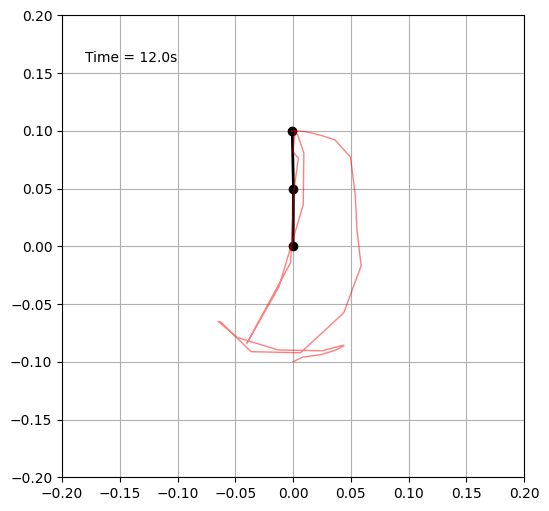

In [33]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

q1 = x_history[:, 0]
q2 = x_history[:, 1]

# Position of the first pendulum bob
x1 = l1 * jnp.sin(q1)
y1 = -l1 * jnp.cos(q1)

# Position of the second pendulum bob
x2 = x1 + l2 * jnp.sin(q1 + q2)
y2 = y1 - l2 * jnp.cos(q1 + q2)

# 2. Set up the animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-(l1 + l2 + 0.1), (l1 + l2 + 0.1))
ax.set_ylim(-(l1 + l2 + 0.1), (l1 + l2 + 0.1))
ax.set_aspect('equal')
ax.grid()

# Plot elements: line for rods, points for masses, and a trace line
line, = ax.plot([], [], 'o-', lw=2, color='black')
trace, = ax.plot([], [], '-', lw=1, color='red', alpha=0.5)
time_template = 'Time = %.1fs'
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)

# History for the trace
trace_x, trace_y = [], []

def init():
	line.set_data([], [])
	trace.set_data([], [])
	time_text.set_text('')
	return line, trace, time_text

def animate(i):
	# Current positions
	thisx = [0, x1[i], x2[i]]
	thisy = [0, y1[i], y2[i]]

	# Update pendulum rods and bobs
	line.set_data(thisx, thisy)

	# Update trace
	trace_x.append(x2[i])
	trace_y.append(y2[i])
	# Keep trace length manageable if needed, or plot full history
	trace.set_data(trace_x, trace_y)

	time_text.set_text(time_template % (i * dt))
	return line, trace, time_text
# Create animation
ani = FuncAnimation(fig, animate, frames=len(time_span_clas),
					init_func=init, interval=dt*1000, blit=True)
plt.rcParams['animation.embed_limit'] = 21.0 # Set embed limit to 21MB

# To display in Jupyter Notebook
HTML(ani.to_jshtml())

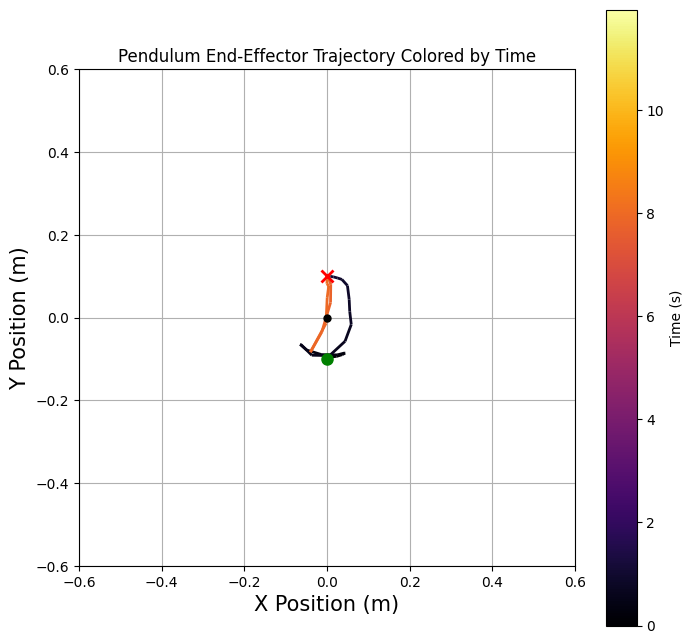

In [34]:
from matplotlib.collections import LineCollection


# --- 1. Data Preparation (Same as your animation setup) ---
q1 = x_history[:, 0]
q2 = x_history[:, 1]

# Position of the first pendulum bob (inner)
x1 = l1 * jnp.sin(q1)
y1 = -l1 * jnp.cos(q1)

# Position of the second pendulum bob (outer - the one we usually track)
x2 = x1 + l2 * jnp.sin(q1 + q2)
y2 = y1 - l2 * jnp.cos(q1 + q2)

# Create a time array for the color mapping
t_points = np.arange(len(x2)) * dt

# --- 2. Create the Gradient Plot ---
fig, ax = plt.subplots(figsize=(8, 8))

# Create a set of line segments so each segment can have a different color
# Points are (x, y) pairs. We connect point i to point i+1
points = np.array([x2, y2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a LineCollection
# 'cmap' controls the color scheme (viridis, plasma, inferno, etc.)
# 'norm' maps the time values to the 0-1 range of the colormap
norm = plt.Normalize(t_points.min(), t_points.max())
lc = LineCollection(segments, cmap='inferno', norm=norm)

# Set the variable used for coloring (time)
lc.set_array(t_points)
lc.set_linewidth(2)

# Add the collection to the plot
ax.add_collection(lc)

# --- 3. Add Visual Reference Points ---
# Plot the starting point (Green Circle)
ax.plot(x2[0], y2[0], 'go', markersize=8, label='Start', zorder=10)

# Plot the end point (Red X)
ax.plot(x2[-1], y2[-1], 'rx', markersize=8, markeredgewidth=2, label='End', zorder=10)

# Plot the pivot point (0,0)
ax.plot(0, 0, 'ko', markersize=5, label='Pivot')

# --- 4. Formatting ---
# Add a colorbar to show the time progression
cbar = fig.colorbar(lc, ax=ax)
cbar.set_label('Time (s)')

ax.set_xlim(-(l1 + l2 + 0.5), (l1 + l2 + 0.5))
ax.set_ylim(-(l1 + l2 + 0.5), (l1 + l2 + 0.5))
ax.set_aspect('equal')
plt.grid()
plt.figsize=(4, 4)
plt.title('Pendulum End-Effector Trajectory Colored by Time')
plt.xlabel('X Position (m)',fontsize=15)
plt.ylabel('Y Position (m)',fontsize=15)
# plt.tight_layout()
# Construct filename from noise matrix

r_diag = base_std * mult
filename = path_prefix + f"Traject_noise_{int(r_diag[0]*1000)}_{int(r_diag[1]*1000)}_{int(r_diag[2]*1000)}_{int(r_diag[3]*1000)}.png"
# Save the plot
plt.show()